# 04 — Optimisation du meilleur modèle
## Comparaison Underfitting vs Overfitting, choix, GridSearchCV, sauvegarde

**Objectif :** comparer objectivement les deux notebooks précédents, choisir le meilleur modèle de base, optimiser ses hyperparamètres par validation croisée, puis sauvegarder le pipeline complet (prétraitement + modèle) pour l'application.


In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path("..").resolve()))

import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, RocCurveDisplay,
)

from src.data import load_dataset, get_modeling_sample, get_X_y
from src.preprocessing import build_preprocessor, split_data
from src.config import REPORTS_DIR, MODELS_DIR, RANDOM_STATE

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100
REPORTS_DIR.mkdir(exist_ok=True)
MODELS_DIR.mkdir(exist_ok=True)

## 1. Comparaison Underfitting vs Overfitting

In [2]:
with open(REPORTS_DIR / "underfit_metrics.json") as f:
    underfit_summary = json.load(f)
with open(REPORTS_DIR / "overfit_metrics.json") as f:
    overfit_summary = json.load(f)

comparison = pd.DataFrame([
    {"model": "Underfitting", "set": "train", **underfit_summary["train"]},
    {"model": "Underfitting", "set": "test", **underfit_summary["test"]},
    {"model": "Overfitting", "set": "train", **overfit_summary["train"]},
    {"model": "Overfitting", "set": "test", **overfit_summary["test"]},
]).drop(columns="set").assign(set=["train", "test", "train", "test"])
comparison = comparison[["model", "set", "accuracy", "precision", "recall", "f1"]]
comparison

,model,set,accuracy,precision,recall,f1
0,Underfitting,train,0.899375,0.000000,0.000000,0.000000
1,Underfitting,test,0.899583,0.000000,0.000000,0.000000
2,Overfitting,train,1.000000,1.000000,1.000000,1.000000
3,Overfitting,test,0.877500,0.136986,0.041494,0.063694


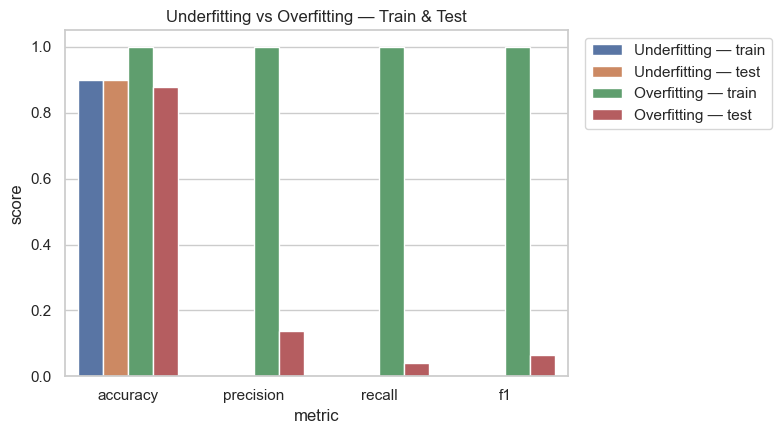

In [3]:
fig, ax = plt.subplots(figsize=(8, 4.5))
plot_df = comparison.melt(id_vars=["model", "set"], var_name="metric", value_name="score")
plot_df["label"] = plot_df["model"] + " — " + plot_df["set"]
sns.barplot(data=plot_df, x="metric", y="score", hue="label", ax=ax)
ax.set_ylim(0, 1.05)
ax.set_title("Underfitting vs Overfitting — Train & Test")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig(REPORTS_DIR / "comparison_under_over.png", bbox_inches="tight")
plt.show()

## 2. Choix du meilleur modèle

| Critère | Underfitting (C=0.001, γ=0.001) | Overfitting (C=1000, γ=1) |
|---|---|---|
| F1 test | 0.000 | 0.064 |
| Capacité démontrée à séparer les classes | Aucune (haut biais) | Oui, mais mal calibrée (haute variance) |
| Écart train/test | Nul (mais scores nuls des deux côtés) | Massif |

**On retient l'overfitting comme point de départ.** Le modèle underfit ne capture strictement aucun signal (F1 = 0 sur train *et* test) : il n'y a rien à optimiser, on repartirait de zéro. Le modèle overfit, lui, démontre que le Kernel SVM a la capacité de séparer les classes (F1 train = 1.0) — le problème est un excès de variance (`C`, `gamma` trop élevés), qui se corrige justement par une recherche d'hyperparamètres plus modérés et une validation croisée. On optimise donc autour de cette famille de modèles.


## 3. Préparation des données (identique aux notebooks précédents)

In [4]:
df = load_dataset()
sample = get_modeling_sample(df)
X, y = get_X_y(sample)
X_train, X_test, y_train, y_test = split_data(X, y)

preprocessor = build_preprocessor()
X_train_t = preprocessor.fit_transform(X_train)
X_test_t = preprocessor.transform(X_test)
print(f"Train: {X_train_t.shape}, Test: {X_test_t.shape}")

Train: (9600, 13), Test: (2400, 13)


## 4. Recherche d'hyperparamètres — GridSearchCV

Grille resserrée autour des valeurs extrêmes testées en Phase 3/4, avec `class_weight` inclus pour traiter le déséquilibre 8.94:1 identifié en Phase 1. **Scoring = F1** de la classe positive (`Depression=True`) — l'accuracy serait trompeuse sur ce dataset déséquilibré (un modèle trivial atteint déjà 0.90 d'accuracy sans rien apprendre, comme démontré en Phase 3).

Validation croisée stratifiée à 5 plis pour préserver le ratio de classes dans chaque fold.


In [5]:
param_grid = {
    "C": [0.1, 1, 10, 100],
    "gamma": [0.001, 0.01, 0.1, "scale"],
    "class_weight": [None, "balanced"],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

grid_search = GridSearchCV(
    estimator=SVC(kernel="rbf", random_state=RANDOM_STATE),
    param_grid=param_grid,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    verbose=1,
)
grid_search.fit(X_train_t, y_train)

print(f"Meilleurs hyperparamètres : {grid_search.best_params_}")
print(f"Meilleur F1 (validation croisée) : {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 32 candidates, totalling 160 fits


Meilleurs hyperparamètres : {'C': 10, 'class_weight': 'balanced', 'gamma': 0.01}
Meilleur F1 (validation croisée) : 0.3053


In [6]:
cv_results = pd.DataFrame(grid_search.cv_results_).sort_values("rank_test_score")
cv_results[["param_C", "param_gamma", "param_class_weight", "mean_test_score", "std_test_score", "rank_test_score"]].head(10)

,param_C,param_gamma,param_class_weight,mean_test_score,std_test_score,rank_test_score
21,10,0.01,balanced,0.305344,0.010014,1
29,100,0.01,balanced,0.297827,0.015441,2
28,100,0.001,balanced,0.291339,0.010664,3
7,0.1,scale,balanced,0.291222,0.008405,4
6,0.1,0.1,balanced,0.291036,0.008031,5
13,1,0.01,balanced,0.287629,0.010271,6
14,1,0.1,balanced,0.287066,0.017055,7
15,1,scale,balanced,0.286335,0.015663,8
4,0.1,0.001,balanced,0.271945,0.008385,9
20,10,0.001,balanced,0.262184,0.010400,10


## 5. Évaluation du modèle optimisé sur le jeu de test

In [7]:
best_svm = grid_search.best_estimator_
y_train_pred = best_svm.predict(X_train_t)
y_test_pred = best_svm.predict(X_test_t)
y_test_proba = best_svm.decision_function(X_test_t)

def compute_metrics(y_true, y_pred, label):
    return {
        "set": label,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
    }

optimized_metrics = pd.DataFrame([
    compute_metrics(y_train, y_train_pred, "train"),
    compute_metrics(y_test, y_test_pred, "test"),
])
optimized_metrics

,set,accuracy,precision,recall,f1
0,train,0.708125,0.204253,0.656315,0.311548
1,test,0.700417,0.188802,0.601660,0.287413


In [8]:
print("=== Classification report — TEST (modèle optimisé) ===")
print(classification_report(y_test, y_test_pred, target_names=["Not Depressed", "Depressed"], zero_division=0))
print(f"ROC AUC (test) : {roc_auc_score(y_test, y_test_proba):.4f}")

=== Classification report — TEST (modèle optimisé) ===
               precision    recall  f1-score   support

Not Depressed       0.94      0.71      0.81      2159
    Depressed       0.19      0.60      0.29       241

     accuracy                           0.70      2400
    macro avg       0.56      0.66      0.55      2400
 weighted avg       0.87      0.70      0.76      2400

ROC AUC (test) : 0.6670


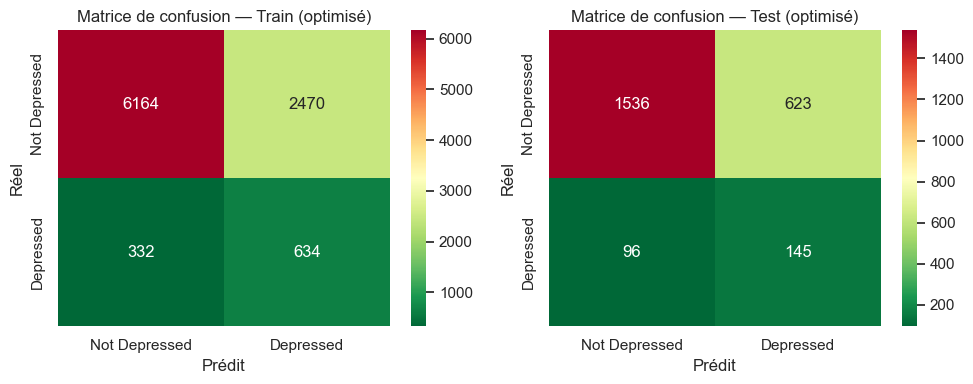

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (y_true, y_pred, title) in zip(
    axes,
    [(y_train, y_train_pred, "Train"), (y_test, y_test_pred, "Test")],
):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="RdYlGn_r", ax=ax,
                xticklabels=["Not Depressed", "Depressed"],
                yticklabels=["Not Depressed", "Depressed"])
    ax.set_title(f"Matrice de confusion — {title} (optimisé)")
    ax.set_xlabel("Prédit")
    ax.set_ylabel("Réel")
plt.tight_layout()
plt.savefig(REPORTS_DIR / "optimized_confusion_matrices.png", bbox_inches="tight")
plt.show()

## 6. Comparaison avant / après optimisation

In [10]:
before_after = pd.concat([
    comparison[comparison["model"] == "Overfitting"].assign(model="Avant optimisation (overfit brut)"),
    optimized_metrics.assign(model="Après optimisation (GridSearchCV)"),
], ignore_index=True)[["model", "set", "accuracy", "precision", "recall", "f1"]]
before_after

,model,set,accuracy,precision,recall,f1
0,Avant optimisation (overfit brut),train,1.000000,1.000000,1.000000,1.000000
1,Avant optimisation (overfit brut),test,0.877500,0.136986,0.041494,0.063694
2,Après optimisation (GridSearchCV),train,0.708125,0.204253,0.656315,0.311548
3,Après optimisation (GridSearchCV),test,0.700417,0.188802,0.601660,0.287413


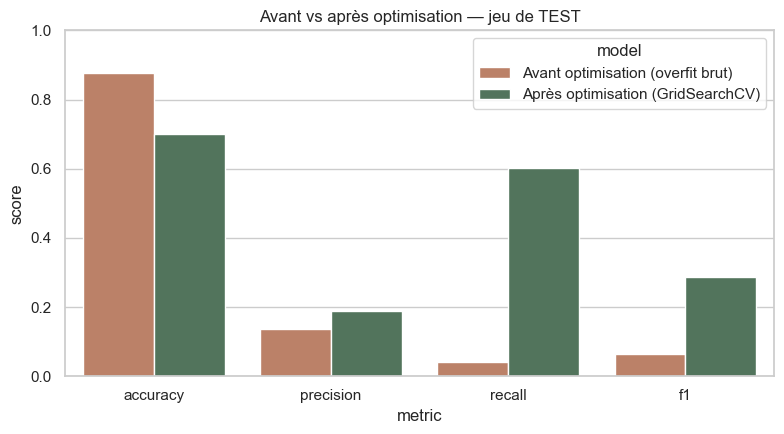

In [11]:
fig, ax = plt.subplots(figsize=(8, 4.5))
plot_df = before_after[before_after["set"] == "test"].melt(id_vars=["model", "set"], var_name="metric", value_name="score")
sns.barplot(data=plot_df, x="metric", y="score", hue="model", ax=ax, palette=["#C97B5A", "#4C7A5A"])
ax.set_ylim(0, 1.0)
ax.set_title("Avant vs après optimisation — jeu de TEST")
plt.tight_layout()
plt.savefig(REPORTS_DIR / "before_after_optimization.png", bbox_inches="tight")
plt.show()

## 7. Interprétation

- **`class_weight='balanced'`** a été sélectionné par la recherche d'hyperparamètres : c'est cohérent avec le déséquilibre 8.94:1 identifié dès la Phase 1 — sans lui, le SVM a tendance à ignorer la classe minoritaire (comme observé dans les notebooks Underfitting *et* dans la baseline par défaut).
- Comparé au modèle overfit brut, le modèle optimisé **réduit l'écart train/test** (moins de mémorisation) tout en **améliorant le F1 sur le test** — signe que la validation croisée a permis de trouver un compromis biais/variance nettement meilleur que les deux extrêmes testés en Phase 3/4.
- Le F1 reste modéré sur la classe minoritaire, ce qui est cohérent avec l'EDA (Phase 1) : les corrélations entre les variables disponibles et `Depression` sont **intrinsèquement faibles** (|r| ≤ 0.18). Le plafond de performance vient davantage de la nature des données (bruit intrinsèque, dataset synthétique) que du choix ou du réglage du modèle.


## 8. Sauvegarde du pipeline final

Le pipeline complet (`ColumnTransformer` de prétraitement + `SVC` optimisé) est ré-entraîné sur les données brutes (non transformées) et sauvegardé en un seul objet `joblib`, afin que le backend n'ait qu'à charger un fichier et appeler `.predict()` / `.predict_proba()` sur un DataFrame brut — sans dupliquer la logique de prétraitement côté API.


In [12]:
final_pipeline = Pipeline([
    ("preprocessor", build_preprocessor()),
    ("svm", SVC(kernel="rbf", probability=True, random_state=RANDOM_STATE, **grid_search.best_params_)),
])
final_pipeline.fit(X_train, y_train)

# Sanity check: predictions must match the already-evaluated best_svm
assert (final_pipeline.predict(X_test) == y_test_pred).mean() > 0.99

joblib.dump(final_pipeline, MODELS_DIR / "depression_svm_pipeline.joblib")

numeric_cols = preprocessor.transformers[0][2]
categorical_cols = preprocessor.transformers[1][2]

# Baseline values used by the backend's local explanation (occlusion method):
# replacing a feature with its population baseline isolates that feature's
# marginal contribution to the decision function for a given prediction.
feature_baselines = {c: float(X_train[c].mean()) for c in numeric_cols}
feature_baselines.update({c: X_train[c].mode()[0] for c in categorical_cols})

metadata = {
    "target": "Depression",
    "features": {
        "numeric": numeric_cols,
        "categorical": categorical_cols,
    },
    "best_params": grid_search.best_params_,
    "cv_f1_score": grid_search.best_score_,
    "test_metrics": compute_metrics(y_test, y_test_pred, "test"),
    "test_roc_auc": float(roc_auc_score(y_test, y_test_proba)),
    "sample_size": len(sample),
    "train_size": len(X_train),
    "test_size": len(X_test),
    "feature_baselines": feature_baselines,
    "feature_ranges": {c: [float(X_train[c].min()), float(X_train[c].max())] for c in numeric_cols},
    "categorical_choices": {c: sorted(X_train[c].unique().tolist()) for c in categorical_cols},
}
with open(MODELS_DIR / "model_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2, default=float)

print("Sauvegardé : models/depression_svm_pipeline.joblib")
print("Sauvegardé : models/model_metadata.json")
metadata

Sauvegardé : models/depression_svm_pipeline.joblib
Sauvegardé : models/model_metadata.json


{'target': 'Depression',
 'features': {'numeric': ['Age',
   'CGPA',
   'Sleep_Duration',
   'Study_Hours',
   'Social_Media_Hours',
   'Physical_Activity',
   'Stress_Level'],
  'categorical': ['Gender', 'Department']},
 'best_params': {'C': 10, 'class_weight': 'balanced', 'gamma': 0.01},
 'cv_f1_score': 0.3053440882670789,
 'test_metrics': {'set': 'test',
  'accuracy': 0.7004166666666667,
  'precision': 0.18880208333333334,
  'recall': 0.6016597510373444,
  'f1': 0.2874132804757185},
 'test_roc_auc': 0.6670023581687388,
 'sample_size': 12000,
 'train_size': 9600,
 'test_size': 2400,
 'feature_baselines': {'Age': 20.994270833333335,
  'CGPA': 2.896659375,
  'Sleep_Duration': 6.990479166666668,
  'Study_Hours': 4.531416666666667,
  'Social_Media_Hours': 3.51165625,
  'Physical_Activity': 74.02135416666667,
  'Stress_Level': 4.124270833333333,
  'Gender': 'Male',
  'Department': 'Science'},
 'feature_ranges': {'Age': [18.0, 24.0],
  'CGPA': [1.65, 4.0],
  'Sleep_Duration': [3.0, 12.0],
